# 06 -- Diagnóstico de `fact_inventario`: ¿existe el Nivel 2?

Sexto notebook de la cadena. **Es una compuerta, no un paso de modelado.**

El Nivel 2 (clasificador de riesgo de quiebre) necesita un target supervisado: saber
cuándo ocurrió un quiebre. La única fuente candidata es `fact_inventario.dias_cobertura`.
Los notebooks 04 y 05 sólo verificaron que *la columna existe*, que no es lo mismo que
verificar que *sirve*.

Un intento previo definió el target como `dias_cobertura <= 2` y obtuvo **0 positivos
sobre 9,6M de filas**. Este notebook averigua por qué, y concluye una de tres cosas:

1. **Nivel 2 viable**: existe un umbral operativo con prevalencia suficiente (>= 0.5%).
2. **Nivel 2 viable con redefinición**: `dias_cobertura` no sirve, pero el stock crudo sí
   permite reconstruir quiebres.
3. **Nivel 2 NO supervisado**: hay que replantearlo como regla determinística sobre el
   pronóstico del Nivel 1, no como modelo entrenado.

Salida: `diagnostico_inventario.json`, que el 07 lee para decidir si construye el target
de Nivel 2 o lo omite.

Cadena: `01_calidad_y_panel` -> `02_regla_priorizacion` -> `03_calendario_estacionalidad`
-> `04_demanda_y_baseline` -> `05_sintesis` -> **`06_diagnostico_inventario`** -> `07_matriz_as_of` -> `08_nivel1_demanda`

In [1]:
import sys
sys.path.insert(0, '.')
from common_priorizacion import PARAMS, DW, registrar_huella, verificar_huella, leer_calendario_habil

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams['figure.figsize'] = (11, 4)

PREVALENCIA_MINIMA = 0.005   # 0.5%: piso para que un clasificador binario sea entrenable
UMBRALES_CANDIDATOS = [0, 1, 2, 3, 5, 7, 10, 15]

# INV-62: el inventario real es una FOTO a una sola fecha (2025-12-31), no una serie
# diaria como la simulacion que este notebook diagnosticaba originalmente. Con una sola
# fecha, 'prevalencia_par_mes' (seccion 3) degenera a prevalencia por fila -- dice que
# HAY filas criticas, pero no que haya suficiente EXTENSION TEMPORAL para que un target
# de ventana de 15 dias habiles tenga sentido (solo los origenes cuya ventana cruza por
# 2025-12-31 verian algun registro). DENSIDAD_MINIMA es el piso explicito para esa otra
# mitad del problema (seccion 5): equivale, aproximadamente, a exigir cobertura de al
# menos un mes calendario completo sobre el panel de dias habiles x pares.
DENSIDAD_MINIMA = 0.05

## 1. Carga con dtypes explícitos

El intento anterior leyó este archivo sin `dtype`, lo que produjo
`DtypeWarning: Columns (0: codigo_item) have mixed types` -- exactamente el fallo que
motivó pasar toda la cadena a parquet con lectores en `common_priorizacion`. Cualquier
diagnóstico hecho sobre esa lectura es poco fiable, así que se repite desde cero.

In [2]:
verificar_huella('huella_01.json', ['panel_diario.parquet', 'calendario_habil.csv'])
fechas_habiles, indice_habil = leer_calendario_habil()

inv = pd.read_csv(
    f'{DW}/fact_inventario.csv',
    dtype={'codigo_item': str, 'sucursal': 'category'},
    parse_dates=['fecha'],
)

print('columnas disponibles:', inv.columns.tolist())
print('filas:', f'{len(inv):,}')
print('dtypes:')
print(inv.dtypes)
assert inv['codigo_item'].map(type).eq(str).all(), 'codigo_item no quedó como str: revisar la lectura'

Huella verificada OK contra huella_01.json.
columnas disponibles: ['codigo_item', 'sucursal', 'fecha', 'stock_disponible', 'stock_minimo', 'stock_maximo', 'punto_reorden', 'dias_cobertura']
filas: 11,035
dtypes:
codigo_item                    str
sucursal                  category
fecha               datetime64[us]
stock_disponible           float64
stock_minimo                 int64
stock_maximo                 int64
punto_reorden                int64
dias_cobertura             float64
dtype: object


## 2. Lo que no se había mirado: la distribución de `dias_cobertura`

Ésta es la celda que faltaba. Un target que da 0 positivos con `<= 2` sobre 9,6M de filas
no es un problema de umbral: o la columna tiene un piso, o un valor centinela, o no
significa lo que se asume.

In [3]:
dc = inv['dias_cobertura']

print('--- ESTADÍSTICOS ---')
print(dc.describe())
print()
print('--- CUANTILES BAJOS (donde vivirían los quiebres) ---')
print(dc.quantile([0, 0.0001, 0.001, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]))
print()
print('--- VALORES EXACTOS MÁS FRECUENTES ---')
print(dc.value_counts().head(15))
print()
print(f'nulos: {dc.isna().sum():,} | negativos: {(dc < 0).sum():,} | exactamente 0: {(dc == 0).sum():,}')
print(f'valor mínimo observado: {dc.min()} | máximo: {dc.max()}')

# Señales de centinela: un máximo redondo y muy repetido (999, 9999) indica "sin límite"
top_valor, top_n = dc.value_counts().index[0], dc.value_counts().iloc[0]
if top_n / len(dc) > 0.05:
    print(f'\nATENCIÓN: el valor {top_valor} concentra {top_n/len(dc):.1%} de las filas -- '
          'posible valor centinela o por defecto, no una medición real.')

--- ESTADÍSTICOS ---
count   11,035.000
mean       118.914
std        229.899
min       -276.300
25%         16.100
50%         45.400
75%        112.800
max      4,016.000
Name: dias_cobertura, dtype: float64

--- CUANTILES BAJOS (donde vivirían los quiebres) ---
0.000    -276.300
0.000    -261.401
0.001     -63.497
0.010      -7.432
0.050       0.000
0.100       1.000
0.250      16.100
0.500      45.400
0.750     112.800
0.950     547.150
0.990     999.000
1.000   4,016.000
Name: dias_cobertura, dtype: float64

--- VALORES EXACTOS MÁS FRECUENTES ---
dias_cobertura
0.000      859
999.000    353
1.000       64
2.000       48
3.000       29
4.000       23
7.900       21
7.000       20
19.200      19
12.700      19
21.200      19
23.500      18
16.100      18
6.800       18
9.500       18
Name: count, dtype: int64

nulos: 0 | negativos: 199 | exactamente 0: 859
valor mínimo observado: -276.3 | máximo: 4016.0

ATENCIÓN: el valor 0.0 concentra 7.8% de las filas -- posible valor centinela o

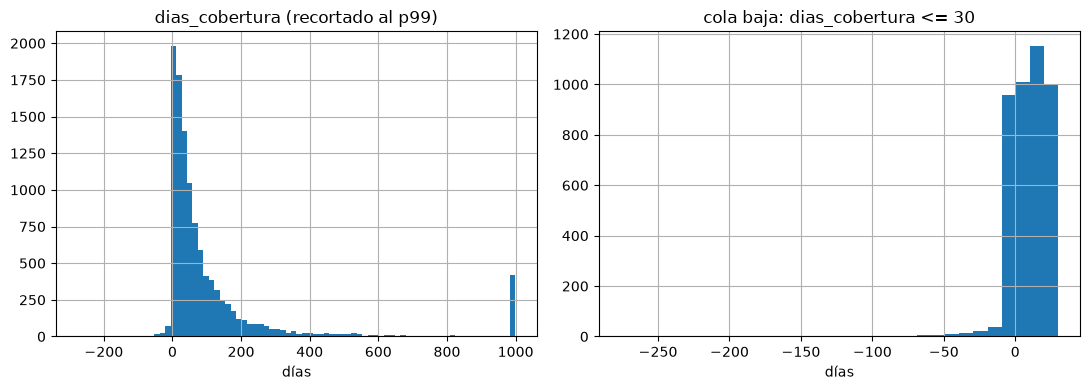

In [4]:
fig, axes = plt.subplots(1, 2)
dc.clip(upper=dc.quantile(0.99)).hist(bins=80, ax=axes[0])
axes[0].set_title('dias_cobertura (recortado al p99)')
axes[0].set_xlabel('días')
dc.loc[dc <= 30].hist(bins=31, ax=axes[1])
axes[1].set_title('cola baja: dias_cobertura <= 30')
axes[1].set_xlabel('días')
plt.tight_layout()
plt.show()

## 3. Prevalencia por umbral candidato

Para cada umbral se reporta la prevalencia **a nivel fila** (par-día) y, lo que de verdad
importa, la prevalencia **a nivel ventana de 15 días hábiles** -- que es el grano del
target del Nivel 2 (`¿hubo al menos un día crítico en los próximos 15?`). La segunda es
siempre mayor y es la que decide si el clasificador es entrenable.

In [5]:
inv_h = inv.loc[inv['fecha'].isin(set(fechas_habiles))].copy()
print(f'filas en días hábiles: {len(inv_h):,} de {len(inv):,}')

filas = []
for u in UMBRALES_CANDIDATOS:
    flag = (inv_h['dias_cobertura'] <= u)
    prev_fila = flag.mean()
    # prevalencia por ventana: fracción de pares que tocan el umbral al menos una vez en
    # cualquier ventana de 15 días hábiles -- se aproxima por par-mes para no expandir 1.4M ventanas
    por_par_mes = (inv_h.assign(flag=flag, mes=inv_h['fecha'].dt.to_period('M'))
                   .groupby(['codigo_item', 'sucursal', 'mes'], observed=True)['flag'].max())
    filas.append({'umbral_dias': u, 'prevalencia_fila': prev_fila,
                  'prevalencia_par_mes': por_par_mes.mean(),
                  'n_positivos_fila': int(flag.sum())})

tabla_umbral = pd.DataFrame(filas)
print(tabla_umbral.to_string(index=False))

viables = tabla_umbral.loc[tabla_umbral['prevalencia_par_mes'] >= PREVALENCIA_MINIMA]
nivel2_viable_dias_cobertura = len(viables) > 0
if nivel2_viable_dias_cobertura:
    umbral_elegido = int(viables['umbral_dias'].min())
    print(f'\nVIABLE: el umbral más estricto con prevalencia >= {PREVALENCIA_MINIMA:.1%} '
          f'es dias_cobertura <= {umbral_elegido}.')
else:
    umbral_elegido = None
    print(f'\nNO VIABLE con dias_cobertura: ningún umbral hasta {max(UMBRALES_CANDIDATOS)} días '
          f'alcanza una prevalencia de {PREVALENCIA_MINIMA:.1%}. Ver sección 4.')

filas en días hábiles: 11,035 de 11,035
 umbral_dias  prevalencia_fila  prevalencia_par_mes  n_positivos_fila
           0             0.096                0.096              1058
           1             0.104                0.104              1145
           2             0.113                0.113              1244
           3             0.121                0.121              1333
           5             0.139                0.139              1531
           7             0.157                0.157              1736
          10             0.186                0.186              2051
          15             0.239                0.239              2637

VIABLE: el umbral más estricto con prevalencia >= 0.5% es dias_cobertura <= 0.


## 4. Ruta alternativa: reconstruir el quiebre desde el stock crudo

Si `dias_cobertura` no sirve, la pregunta siguiente es si hay una columna de stock físico
con la que se pueda definir el quiebre directamente (`stock == 0` con demanda esperada > 0).
Esta celda busca candidatas y evalúa la mejor.

In [6]:
candidatas_stock = [c for c in inv.columns
                    if any(k in c.lower() for k in ('stock', 'existencia', 'disponible', 'cantidad', 'saldo'))]
print('columnas candidatas a stock físico:', candidatas_stock)

col_stock, prevalencia_stock = None, np.nan
for c in candidatas_stock:
    if not pd.api.types.is_numeric_dtype(inv_h[c]):
        continue
    prev = (inv_h[c] <= 0).mean()
    print(f'  {c}: {(inv_h[c] <= 0).sum():,} filas con valor <= 0 ({prev:.2%}), '
          f'nulos {inv_h[c].isna().mean():.2%}')
    if prev >= PREVALENCIA_MINIMA and (col_stock is None or prev > prevalencia_stock):
        col_stock, prevalencia_stock = c, prev

nivel2_viable_stock = col_stock is not None
if nivel2_viable_stock:
    print(f'\nVIABLE por stock crudo: columna `{col_stock}` con {prevalencia_stock:.2%} de par-día en cero.')
elif not candidatas_stock:
    print('\nNo hay ninguna columna de stock físico en fact_inventario.')
else:
    print('\nNinguna columna de stock alcanza la prevalencia mínima.')

columnas candidatas a stock físico: ['stock_disponible', 'stock_minimo', 'stock_maximo']
  stock_disponible: 1,102 filas con valor <= 0 (9.99%), nulos 0.00%
  stock_minimo: 0 filas con valor <= 0 (0.00%), nulos 0.00%
  stock_maximo: 0 filas con valor <= 0 (0.00%), nulos 0.00%

VIABLE por stock crudo: columna `stock_disponible` con 9.99% de par-día en cero.


## 5. Densidad del panel y qué significa la ausencia de fila

La densidad del panel de inventario es la otra mitad del problema. Si un tercio de los
par-día no tiene registro, hay que saber **qué** es esa ausencia antes de imputarla: si
coincide con productos fuera de catálogo es inocua, pero si coincide con quiebres, rellenar
con 0 estaría etiquetando el evento de interés como su contrario.

La prueba: comparar la venta del día siguiente entre par-día **con** registro y **sin**
registro. Si la ausencia fuera un quiebre, la venta posterior debería caer.

In [7]:
n_pares_inv = inv_h[['codigo_item', 'sucursal']].drop_duplicates().shape[0]
densidad = len(inv_h) / (n_pares_inv * len(fechas_habiles))
print(f'pares en inventario: {n_pares_inv:,} | días hábiles: {len(fechas_habiles)} | densidad: {densidad:.2%}')

diario = pd.read_parquet(f'{DW}/panel_diario.parquet')
pares_inv = set(map(tuple, inv_h[['codigo_item', 'sucursal']].drop_duplicates().to_numpy()))

# marca de presencia en inventario por (par, fecha)
presencia = inv_h[['codigo_item', 'sucursal', 'fecha']].drop_duplicates().assign(tiene_registro=True)
ventas_dia = diario.groupby(['codigo_item', 'sucursal', 'fecha'], observed=True)['unidades'].sum().reset_index()
cruce = ventas_dia.merge(presencia, on=['codigo_item', 'sucursal', 'fecha'], how='left')
cruce['tiene_registro'] = cruce['tiene_registro'].fillna(False)

resumen_presencia = cruce.groupby('tiene_registro')['unidades'].agg(['count', 'mean', 'median'])
print()
print('Venta del día, según haya o no registro de inventario ese día:')
print(resumen_presencia)
print()
print('LECTURA: si la venta media con registro y sin registro es similar, la ausencia es'
      ' principalmente cobertura de catálogo (inocua). Si la venta sin registro es'
      ' marcadamente menor, la ausencia está correlacionada con el quiebre y NO puede'
      ' imputarse como 0 = sin quiebre.')

pares en inventario: 11,035 | días hábiles: 1060 | densidad: 0.09%



Venta del día, según haya o no registro de inventario ese día:
                  count  mean  median
tiene_registro                       
False           1414881 2.914   1.000
True               2305 4.338   2.000

LECTURA: si la venta media con registro y sin registro es similar, la ausencia es principalmente cobertura de catálogo (inocua). Si la venta sin registro es marcadamente menor, la ausencia está correlacionada con el quiebre y NO puede imputarse como 0 = sin quiebre.


## 6. Veredicto y exportación de la compuerta

El 07 lee este JSON. Si `nivel2_supervisado` es `False`, **no construye** el target de
Nivel 2 y el Nivel 2 pasa a ser una regla determinística sobre el pronóstico del Nivel 1
(`P(demanda_15d > stock_actual)` usando el cuantil ya estimado), no un modelo entrenado.
Esa es una conclusión publicable, no un fracaso: documenta una limitación real del dato.

In [8]:
# INV-62: se agrega el piso de densidad como condicion explicita, no solo informativa --
# con una sola fecha de inventario real, la prevalencia por fila/par-mes de la seccion 3
# puede ser alta (ej. stock negativo observado ESE dia) sin que exista extension temporal
# real para sostener un target de ventana de 15 dias habiles.
densidad_suficiente = densidad >= DENSIDAD_MINIMA
nivel2_viable_dias_cobertura = nivel2_viable_dias_cobertura and densidad_suficiente
nivel2_viable_stock = nivel2_viable_stock and densidad_suficiente

if nivel2_viable_dias_cobertura:
    definicion = f'dias_cobertura <= {umbral_elegido}'
    fuente, umbral = 'dias_cobertura', umbral_elegido
elif nivel2_viable_stock:
    definicion = f'{col_stock} <= 0'
    fuente, umbral = col_stock, 0
else:
    definicion, fuente, umbral = None, None, None

if not densidad_suficiente:
    print(f'AVISO: densidad del panel ({densidad:.2%}) por debajo del piso ({DENSIDAD_MINIMA:.0%}) -- '
          f'la prevalencia de la seccion 3 no alcanza para sostener un target temporal, aunque haya '
          f'filas individuales criticas. Ver seccion 5.')

diagnostico = {
    'nivel2_supervisado': bool(nivel2_viable_dias_cobertura or nivel2_viable_stock),
    'fuente_target': fuente,
    'umbral_target': umbral,
    'definicion_target': definicion,
    'prevalencia_minima_exigida': PREVALENCIA_MINIMA,
    'densidad_minima_exigida': DENSIDAD_MINIMA,
    'densidad_suficiente': bool(densidad_suficiente),
    'densidad_panel_inventario': float(densidad),
    'dias_cobertura_min': float(dc.min()),
    'dias_cobertura_p01': float(dc.quantile(0.01)),
    'dias_cobertura_mediana': float(dc.median()),
    'tabla_umbrales': tabla_umbral.to_dict('records'),
}

with open(f'{DW}/diagnostico_inventario.json', 'w') as f:
    json.dump(diagnostico, f, indent=2, ensure_ascii=False)

print('=' * 70)
if diagnostico['nivel2_supervisado']:
    print(f'VEREDICTO: el Nivel 2 ES supervisable. Target = {definicion}.')
    print('El 07 construirá target_quiebre_binario con tres estados (1 / 0 / NaN si no hay registro).')
else:
    print('VEREDICTO: el Nivel 2 NO es supervisable con los datos actuales.')
    print('Replantearlo como regla determinística sobre el pronóstico del Nivel 1.')
    print('Esto debe quedar escrito en la tesis como limitación del dato, con esta tabla como evidencia.')
print('=' * 70)

huella = {
    'notebook': '06_diagnostico_inventario',
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'entradas': registrar_huella(['fact_inventario.csv', 'panel_diario.parquet', 'calendario_habil.csv']),
    'salidas': registrar_huella(['diagnostico_inventario.json']),
}
with open(f'{DW}/huella_06.json', 'w') as f:
    json.dump(huella, f, indent=2, ensure_ascii=False)
print('guardado: diagnostico_inventario.json + huella_06.json')

AVISO: densidad del panel (0.09%) por debajo del piso (5%) -- la prevalencia de la seccion 3 no alcanza para sostener un target temporal, aunque haya filas individuales criticas. Ver seccion 5.
VEREDICTO: el Nivel 2 NO es supervisable con los datos actuales.
Replantearlo como regla determinística sobre el pronóstico del Nivel 1.
Esto debe quedar escrito en la tesis como limitación del dato, con esta tabla como evidencia.
guardado: diagnostico_inventario.json + huella_06.json
